## 函式庫

In [62]:
import torch
import torch.nn as nn
import torch.optim as optim
import clip
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, random_split
from PIL import Image
import pandas as pd
import numpy as np
import os

## 下載資料集

In [63]:
#!/bin/bash
#! kaggle datasets download darkfanxing/ntutemnist

In [64]:
#! unzip ntutemnist.zip -d ntutemnist_data

## 檢查資料

In [65]:
DATA_DIR = 'ntutemnist_data/'
TRAIN_DATA_FILE = DATA_DIR + 'emnist-byclass-train.npz'
TEST_DATA_FILE = DATA_DIR + 'emnist-byclass-test.npz'
train_data = np.load(TRAIN_DATA_FILE)
test_data = np.load(TEST_DATA_FILE)
train_images = train_data['training_images']
train_labels = train_data['training_labels']
test_images = test_data['testing_images']

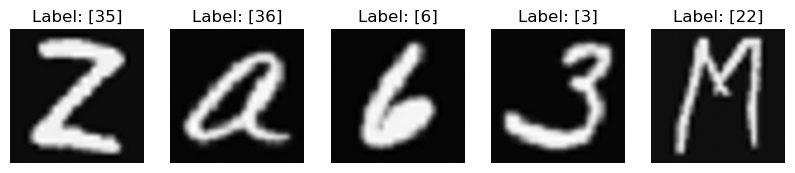

Shape of the first resized image: (224, 224)


In [78]:
# 定義函數將每張圖片從 28x28 調整為 224x224，這次只處理前5張圖片
def resize_images(images, size=(224, 224), num_images=5):
    resized_images = []
    for img in images[:num_images]:  # 只處理前 5 張圖片
        img_pil = Image.fromarray(img.squeeze())  # 去掉多餘的維度，28x28 -> 28x28
        img_resized = img_pil.resize(size)  # 調整大小到 224x224
        resized_images.append(np.array(img_resized))
    return np.array(resized_images)

# 將前 5 張訓練圖片進行 resize
train_images_resized = resize_images(train_images, size=(224, 224), num_images=5)

# 顯示調整後的圖片
import matplotlib.pyplot as plt

def show_images(images, labels, num=5):
    plt.figure(figsize=(10, 5))
    for i in range(num):
        plt.subplot(1, num, i+1)
        plt.imshow(images[i], cmap='gray')  # 確保影像是灰階
        plt.title(f"Label: {labels[i]}")
        plt.axis("off")
    plt.show()

# 顯示前 5 張調整過大小的圖片
show_images(train_images_resized, train_labels[:5], num=5)
print("Shape of the first resized image:", train_images_resized[0].shape)


## Model引入

In [67]:
# 設置設備
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device}")

# 載入 CLIP 模型，這裡我們使用 'ViT-B/32'
clip_model, preprocess = clip.load("ViT-B/32", device=device)

# 凍結 CLIP 權重
for param in clip_model.parameters():
    param.requires_grad = False

print(clip_model.visual)

Using cuda
VisionTransformer(
  (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
  (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (transformer): Transformer(
    (resblocks): Sequential(
      (0): ResidualAttentionBlock(
        (attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): Sequential(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (gelu): QuickGELU()
          (c_proj): Linear(in_features=3072, out_features=768, bias=True)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
      (1): ResidualAttentionBlock(
        (attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (ln_1): LayerNorm((768,), eps=1e-05, 

## 數據預處理

In [100]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # CLIP 需要 RGB
    transforms.Resize((224, 224)),  
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.5], std=[0.5])
])


test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # 測試集相同處理
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.5], std=[0.5])
])



## 自定義 Dataset

In [92]:
class EMNISTDataset(Dataset):
    def __init__(self, npz_path, transform=None, has_labels=True):
        # 讀取 npz 檔案
        data = np.load(npz_path)
        
        # 提取影像並去掉最後一個通道維度
        self.images = data["training_images" if has_labels else "testing_images"]  
        #self.images = self.images.squeeze(-1).astype(np.uint8)   
                # 根據影像維度進行調整
        if len(self.images.shape) > 3:
            # 如果有額外的維度 (例如通道維度)，進行 squeeze
            self.images = self.images.squeeze(-1)
        
        # 檢查數據範圍並歸一化
        if self.images.max() <= 1.0 and self.images.min() >= 0:
            # 如果數據範圍是 [0, 1]，轉換為 [0, 255]
            self.images = (self.images * 255).astype(np.uint8)
        elif self.images.max() > 1.0 and self.images.max() <= 255:
            # 如果數據已在 [0, 255] 範圍內，確保類型為 uint8
            self.images = self.images.astype(np.uint8)
        else:
            # 如果數據範圍異常，進行最小最大值歸一化
            self.images = ((self.images - self.images.min()) / 
                         (self.images.max() - self.images.min() + 1e-8) * 255).astype(np.uint8)
        

        # 提取標籤（如果有）
        self.labels = data["training_labels"] if has_labels else None
        self.transform = transform
        self.has_labels = has_labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # 轉換為 PIL 影像
        image = Image.fromarray(self.images[idx])

        if self.transform:
            image = self.transform(image)

        if self.has_labels:
            label = int(self.labels[idx].item())  # 轉換為純量
            return image, label
        
        return image,  # 注意這裡要回傳 tuple


## 定義 CLIP + MLP

In [79]:
class CLIP_EMNIST_Model(nn.Module):
    def __init__(self, clip_model, num_classes=62):
        super(CLIP_EMNIST_Model, self).__init__()
        self.clip_visual = clip_model.visual  # CLIP 的影像 encoder
        self.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)  # 分類 62 個類別
        )

    def forward(self, x):
        with torch.no_grad():  # 凍結 CLIP
            features = self.clip_visual(x)
        return self.fc(features)


## 訓練 & 驗證

Image batch shape: torch.Size([3, 224, 224])
Image batch shape: torch.Size([128, 3, 224, 224])


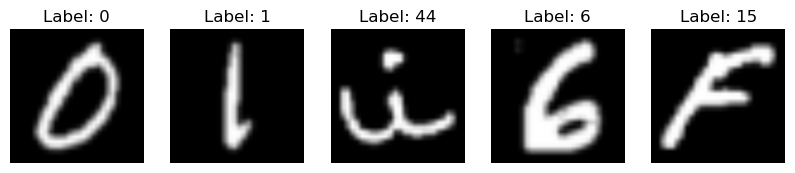

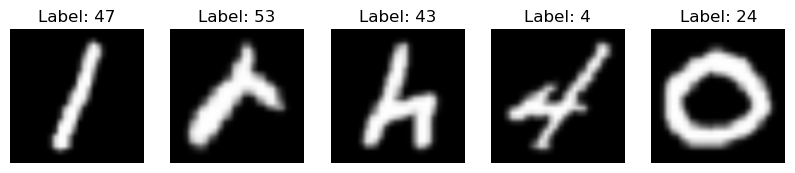

In [ ]:
# # 讀取數據
# train_dataset = EMNISTDataset("ntutemnist_data/emnist-byclass-train.npz", transform=train_transform)
# test_dataset = EMNISTDataset("ntutemnist_data/emnist-byclass-test.npz", transform=test_transform, has_labels=False)


# # 切割 20% 訓練集作為驗證集
# val_size = int(0.2 * len(train_dataset))
# train_size = len(train_dataset) - val_size
# train_data, val_data = random_split(train_dataset, [train_size, val_size])

# # DataLoader
# train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
# val_loader = DataLoader(val_data, batch_size=128, shuffle=False)
# test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


# # 檢查圖片轉換後的大小
# def check_image_size(loader):
#     # 從 DataLoader 中取出一個 batch
#     images, _ = next(iter(loader))  # 這裡假設 loader 會返回 image 和 label
#     print(f"Image batch shape: {images.shape}")  # 打印圖片的 shape

# # 檢查訓練集轉換後的圖片大小
# check_image_size(train_dataset)

# # 檢查驗證集轉換後的圖片大小
# check_image_size(val_loader)


# def show_images(loader, num_images=5):
#     # 從 DataLoader 中取出一個 batch
#     images, labels = next(iter(loader))  # 假設 loader 會返回 image 和 label
    
#     # 轉換為 numpy 陣列以便使用 matplotlib 顯示
#     images = images.numpy()  # 這是將 pytorch tensor 轉換為 numpy 陣列
    
#     # 顯示前 num_images 張圖片
#     plt.figure(figsize=(10, 10))
#     for i in range(num_images):
#         plt.subplot(1, num_images, i+1)
#         img = images[i].transpose(1, 2, 0)  # 轉換維度為 (H, W, C)
#         plt.imshow(img.squeeze(), cmap='gray')  # 轉換為灰階圖片（若是單通道）
#         plt.title(f"Label: {labels[i].item()}")
#         plt.axis("off")
#     plt.show()

# # 顯示訓練集前 5 張圖片
# show_images(train_loader, num_images=5)
# show_images(val_loader, num_images=5)

Images Type: <class 'torch.Tensor'>
Labels Type: <class 'torch.Tensor'>
Images Shape: torch.Size([128, 3, 224, 224])
Labels Shape: torch.Size([128])


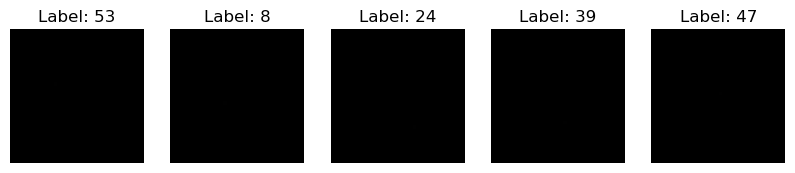

Images Type: <class 'torch.Tensor'>
Labels Type: <class 'torch.Tensor'>
Images Shape: torch.Size([128, 3, 224, 224])
Labels Shape: torch.Size([128])


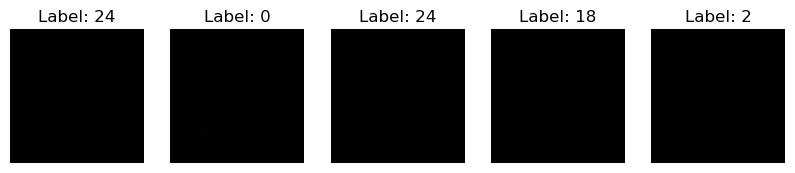

cuda


KeyboardInterrupt: 

In [ ]:
from tqdm import tqdm
# 讀取數據
train_dataset = EMNISTDataset("ntutemnist_data/emnist-byclass-train.npz", transform=train_transform)
test_dataset = EMNISTDataset("ntutemnist_data/emnist-byclass-test.npz", transform=test_transform, has_labels=False)


# 切割 20% 訓練集作為驗證集
val_size = int(0.2 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_data, val_data = random_split(train_dataset, [train_size, val_size])

# DataLoader
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

#================================================ 檢查 ==============================================
# 檢查圖片轉換後的大小
def check_image_size(loader):
    # 從 DataLoader 中取出一個 batch
    images, _ = next(iter(loader))  # 這裡假設 loader 會返回 image 和 label
    print(f"Image batch shape: {images.shape}")  # 打印圖片的 shape

# 檢查訓練集轉換後的圖片大小
check_image_size(train_dataset)

# 檢查驗證集轉換後的圖片大小
check_image_size(val_loader)


def show_images(loader, num_images=5):
    # 從 DataLoader 中取出一個 batch
    images, labels = next(iter(loader))  # 假設 loader 會返回 image 和 label
    
    # 轉換為 numpy 陣列以便使用 matplotlib 顯示
    images = images.numpy()  # 這是將 pytorch tensor 轉換為 numpy 陣列
    
    # 顯示前 num_images 張圖片
    plt.figure(figsize=(10, 10))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        img = images[i].transpose(1, 2, 0)  # 轉換維度為 (H, W, C)
        plt.imshow(img.squeeze(), cmap='gray')  # 轉換為灰階圖片（若是單通道）
        plt.title(f"Label: {labels[i].item()}")
        plt.axis("off")
    plt.show()

# 顯示訓練集前 5 張圖片
show_images(train_loader, num_images=5)
show_images(val_loader, num_images=5)

#=================================================================================================

# 初始化模型
model = CLIP_EMNIST_Model(clip_model).to(torch.float32).to(device)
print(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.0001)

from tqdm import tqdm  # 引入 tqdm

# 訓練
def train(model, train_loader, val_loader, epochs):
    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        # 使用 tqdm 包裝 train_loader 以顯示進度條
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        # 計算訓練集準確度
        train_acc = correct / total
        # 計算驗證集準確度
        val_acc = evaluate(model, val_loader)
        
        print(f"Epoch {epoch+1}/{epochs}: Loss={total_loss/len(train_loader):.4f}, Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

def evaluate(model, val_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return correct / total

# 開始訓練
train(model, train_loader, val_loader, epochs=20)



## 測試 & 預測

In [ ]:
def predict(model, test_loader):
    model.eval()
    predictions = []
    with torch.no_grad():
        for images in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            predictions.extend(predicted.cpu().numpy())

    return predictions

# 預測
test_predictions = predict(model, test_loader)

# 儲存結果
pd.DataFrame({"Predicted": test_predictions}).to_csv("/kaggle/working/emnist_predictions.csv", index=False)
print("預測結果已儲存至 emnist_predictions.csv")
